# Gradus: CNN on scikit-learn `digits`

Phase 3 functional-correctness demo: a small CNN (`Conv2d` -> `BatchNorm2d` -> `ReLU`, twice, with a stride-2 second conv for downsampling instead of a separate max-pool layer) trained end-to-end with Gradus's own autograd engine, `Adam` optimizer, and `Trainer` loop.

**Why `digits` instead of CIFAR-10:** the original plan was CIFAR-10, but this was developed in a sandbox with no GPU and no network access to download it. `digits` ships inside scikit-learn (1797 8x8 grayscale images, 10 classes, no download needed) and proves the same thing -- a real CNN stack training to convergence -- at a scale a CPU-only environment can actually run. The full CIFAR-10 + GPU run is Phase 4-5, on Kaggle (see `../BENCHMARK_REPORT.md`).

See `../docs/API.md` for the full API reference used below.

In [1]:
import time

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from gradus import Tensor, Trainer
from gradus.nn import BatchNorm2d, Conv2d, CrossEntropyLoss, Linear, Module, ReLU
from gradus.optim import Adam

## Model

An "all-convolutional net" (Springenberg et al., 2014): downsampling via a stride-2 `Conv2d` rather than a separate max-pool layer, which avoids needing a new argmax-routing backward primitive while remaining a standard CNN design.

In [2]:
class DigitsCNN(Module):
    def __init__(self):
        self.conv1 = Conv2d(1, 8, kernel_size=3, stride=1, padding=1)
        self.bn1 = BatchNorm2d(8)
        self.relu1 = ReLU()
        self.conv2 = Conv2d(8, 16, kernel_size=3, stride=2, padding=1)  # 8x8 -> 4x4
        self.bn2 = BatchNorm2d(16)
        self.relu2 = ReLU()
        self.fc = Linear(16 * 4 * 4, 10)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = x.reshape(x.shape[0], -1)
        return self.fc(x)

## Data

Pixel values scaled to `[0, 1]`; an 80/20 stratified train/test split.

In [3]:
np.random.seed(0)
rng = np.random.default_rng(0)

digits = load_digits()
x = digits.images.astype(np.float64) / 16.0  # pixel values are 0-16
x = x[:, None, :, :]  # (N, 1, 8, 8) -- add channel dim
y = digits.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0, stratify=y
)
print(f'train: {x_train.shape[0]} samples, test: {x_test.shape[0]} samples')

train: 1437 samples, test: 360 samples


## Training

In [4]:
def make_batches(x, y, batch_size, rng):
    n = x.shape[0]
    indices = rng.permutation(n)
    for start in range(0, n, batch_size):
        idx = indices[start : start + batch_size]
        yield Tensor(x[idx]), y[idx]


class BatchesIterable:
    """Trainer.fit() re-iterates its `batches` argument once per epoch --
    wrapping the generator function in an object with __iter__ gives it a
    fresh generator each time."""

    def __init__(self, gen_fn):
        self.gen_fn = gen_fn

    def __iter__(self):
        return self.gen_fn()

In [5]:
model = DigitsCNN()
print(f'model parameters: {model.num_parameters():,}')

optimizer = Adam(model.parameters(), lr=1e-3)
trainer = Trainer(model, optimizer, CrossEntropyLoss())

epochs = 15
batch_size = 32
start = time.time()

def batches():
    return make_batches(x_train, y_train, batch_size, rng)

def log_epoch(epoch, loss, metric):
    print(f'epoch {epoch + 1:2d}/{epochs}  train_loss={loss:.4f}  train_acc={metric:.4f}')

history = trainer.fit(
    BatchesIterable(batches), epochs=epochs, metric_fn=Trainer.accuracy,
    on_epoch_end=log_epoch,
)
elapsed = time.time() - start

model parameters: 3,866


epoch  1/15  train_loss=1.5584  train_acc=0.6448


epoch  2/15  train_loss=0.5680  train_acc=0.9326


epoch  3/15  train_loss=0.2906  train_acc=0.9624


epoch  4/15  train_loss=0.1924  train_acc=0.9728
epoch  5/15  train_loss=0.1449  train_acc=0.9792


...

epoch  9/15  train_loss=0.0626  train_acc=0.9944


epoch 10/15  train_loss=0.0507  train_acc=0.9958
epoch 11/15  train_loss=0.0452  train_acc=0.9951


epoch 12/15  train_loss=0.0374  train_acc=0.9972
epoch 13/15  train_loss=0.0321  train_acc=0.9979


epoch 14/15  train_loss=0.0270  train_acc=0.9986


epoch 15/15  train_loss=0.0233  train_acc=1.0000


## Held-out evaluation

In [6]:
model.eval()
test_pred = model(Tensor(x_test))
test_acc = Trainer.accuracy(test_pred, y_test)

print(f'training time: {elapsed:.1f}s ({epochs} epochs, CPU)')
print(f'final train loss: {history["loss"][-1]:.4f}')
print(f'final train accuracy: {history["metric"][-1]:.4f}')
print(f'held-out test accuracy: {test_acc:.4f}')

training time: 3.8s (15 epochs, CPU)
final train loss: 0.0233
final train accuracy: 1.0000
held-out test accuracy: 0.9778


## Convergence plot

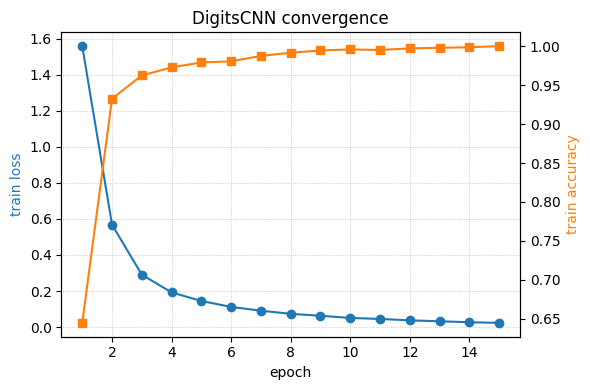

In [7]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(6, 4))
epochs_range = range(1, epochs + 1)
ax1.plot(epochs_range, history['loss'], marker='o', color='tab:blue', label='train loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('train loss', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(epochs_range, history['metric'], marker='s', color='tab:orange', label='train accuracy')
ax2.set_ylabel('train accuracy', color='tab:orange')
ax1.set_title('DigitsCNN convergence')
ax1.grid(True, linestyle=':', linewidth=0.5)
fig.tight_layout()
plt.show()